<a href="https://colab.research.google.com/github/prishabobde/CS_181_ComputerVision/blob/main/CS_181_HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Image Generation

import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage
from scipy.ndimage import rotate
from scipy.signal import convolve2d


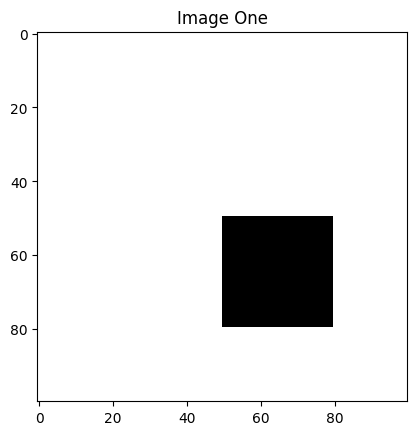

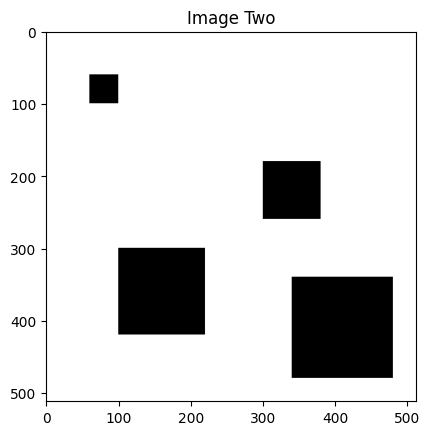

In [ ]:
#generating image 1 --> single black square; left corner at coord 50x50
imageOne = np.ones((100,100))

x, y = 50, 50
size = 30

imageOne[y:y+size, x:x+size] = 0   #black = 0

plt.imshow(imageOne, cmap = 'gray', vmin= 0, vmax = 1)
plt.title("Image One")
plt.show()

#generating image 2
imageTwo = np.ones((512,512))

x, y = 60, 60
size = 40
imageTwo[y:y+size, x:x+size] = 0

x, y = 300, 180
size = 80
imageTwo[y:y+size, x:x+size] = 0

x, y = 100, 300
size = 120
imageTwo[y:y+size, x:x+size] = 0

x, y = 340, 340
size = 140
imageTwo[y:y+size, x:x+size] = 0

plt.imshow(imageTwo, cmap = 'gray', vmin= 0, vmax = 1)
plt.title("Image Two")
plt.show()


## Single Square Image

a) Applying Gaussian smoothing at scales: 1, 2, 4, 8 and then computing the Harris Corner Response function.

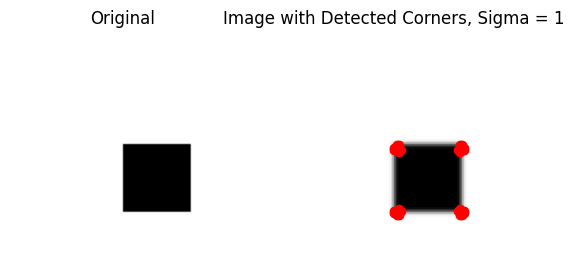

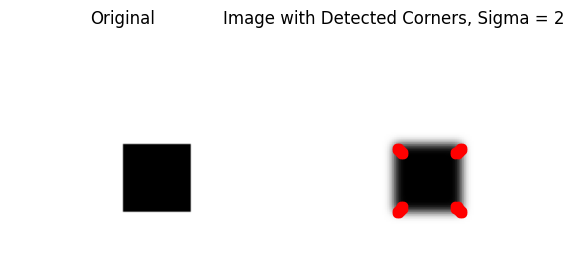

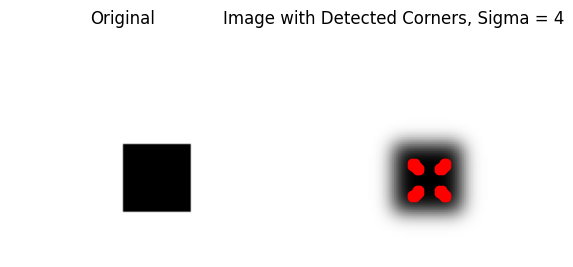

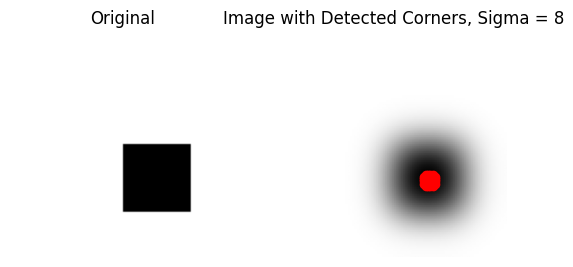

In [ ]:
sigmas = [1, 2, 4, 8]


#Harris corner from HW 1


def HarrisCornerDetector(image, originalImage, currSigma, coord_list, k = 0.05, numTop = 40, plot=False):

  # First computing gradients
  # Calculating Ix and Iy using Sobel operators
  Sx = np.array([[-1, 0, 1],
      [-2, 0, 2],
      [-1, 0, 1]])
  Sy = np.array([[-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]])

  Ix = ndimage.convolve(image, Sx)
  Iy = ndimage.convolve(image, Sy)

  Ixx = Ix**2
  Iyy = Iy**2
  Ixy = Ix * Iy

  #all given equal weight --> 3 x 3
  averaging = np.array([
      [1/9, 1/9, 1/9],
      [1/9, 1/9, 1/9],
      [1/9, 1/9, 1/9]
  ])

  #finding A matrices
  #each value is an array (2D) --> need to average it to get the values of A
  Axx = convolve2d(Ixx, averaging)  #averaged
  Ayy = convolve2d(Iyy, averaging)
  Axy = convolve2d(Ixy, averaging)

  #crf
  detA = (Axx * Ayy) - Axy**2
  trace = Axx + Ayy         #sum of diagonal elements
  crf = detA - k*((trace)**2)

  #print out all crf values --> the size of all pixels
  #print("CRF:",crf)

  #threshold
  threshold = 0.01 * crf.max()
  meet_threshold = np.argwhere(crf > threshold)   #coordinates
  crf_values_in_range = crf[crf > threshold]

  #sorting based on crf values high to low
  topIndices = (-crf_values_in_range).argsort()[:numTop]     #negative switches the order
  topValuesInOrder = crf_values_in_range[topIndices]
  coordinatesMeetingThresholdOrdered = meet_threshold[topIndices]

  #outputing
  # print("Top 40 coordinates ordered by descending CRF:")

  # print("x   | y   | CRF")
  # print("---------------")

  # for (y, x), val in zip(coordinatesMeetingThresholdOrdered, topValuesInOrder):       #since numpy is row, col
  #   print(x, " | ", y, " | ", str(round(val)))

  coord_list.extend([(y,x,currSigma) for y,x in coordinatesMeetingThresholdOrdered])

  if plot:
    #print both images side by side
    plt.subplot(1,2,1)        #1 row, 2 cols, 1rst subplot
    plt.imshow(originalImage, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    #second image --> red dots indicated corners
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')
    for(y,x), val in zip(coordinatesMeetingThresholdOrdered, topValuesInOrder):
      plt.plot(x,y, 'ro')
    plt.title(f"Image with Detected Corners, Sigma = {currSigma}")
    plt.axis("off")
    plt.show()

Harr_coords_imageOne = []

for currSigma in sigmas:
  smoothed = ndimage.gaussian_filter(imageOne, sigma = currSigma)
  HarrisCornerDetector(smoothed, imageOne, currSigma, Harr_coords_imageOne,  plot=True)



b) Applying the Laplacian of the Gaussian at the same sigmas

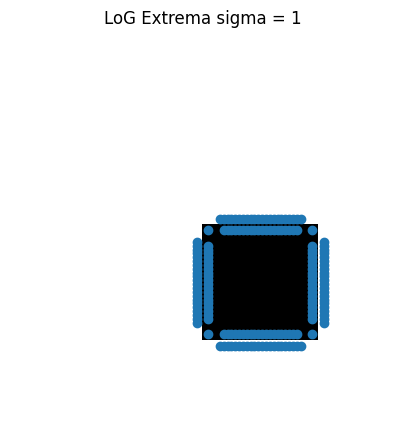

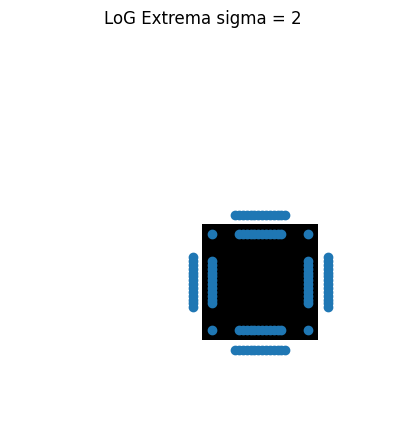

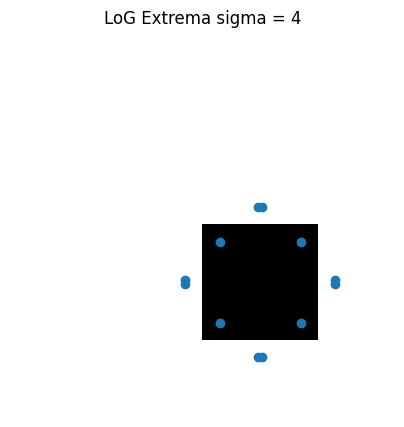

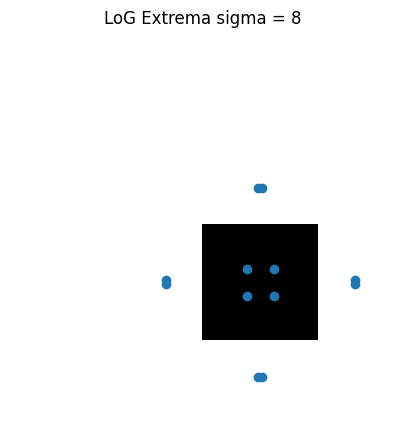

In [ ]:
def LoG(image, sigmas, coord_list, plot = True):
  height, width = image.shape
  n = 4   # 4 sigmas
  rows = 2
  cols = 2

  for currSigma in sigmas:

    #LoG
    LoG_image = ndimage.gaussian_laplace(image, sigma=currSigma)

    #normalize by multiplying with sigma squared
    LoG_image = (currSigma ** 2) * LoG_image

    threshold = 0.05 * np.max(np.abs(LoG_image)) # 5% --> from canvas clarification

    coordinates = []      #to collect corner / interest points

    #looping through all pixels except borders
    for row in range(1, height - 1):
      for col in range(1, width - 1):
        value = LoG_image[row, col]           #curr pixel value

        #skipping weak responses
        if abs(value) < threshold:
          continue

        #extract a 3x3 local patch around (row, col)
        patch = LoG_image[row-1 : row+2, col-1:col+2]

        #checking if current pixel = unique extrema by local magnitude
        if abs(value) == np.max(np.abs(patch)):
          coordinates.append((row,col))   #store local max point
          coord_list.append((row, col, currSigma))


    if plot:
      plt.figure(figsize=(5,5))
      plt.imshow(image, cmap="gray")

      if coordinates:
        coords = np.array(coordinates)
        plt.scatter(coords[:,1], coords[:,0])

      plt.title(f"LoG Extrema sigma = {currSigma}")
      plt.axis("off")
      plt.show()
  return coord_list


LoG_imageOne_coords = []

LoG_imageOne_coords = LoG(imageOne, sigmas, LoG_imageOne_coords)


c) Apply the DoG operator using the same sigma values with k ~ 1.4 between consecutive scales.

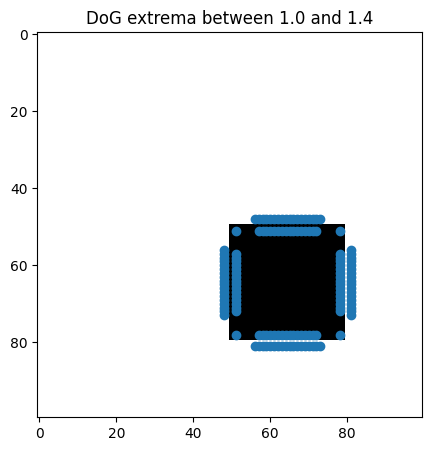

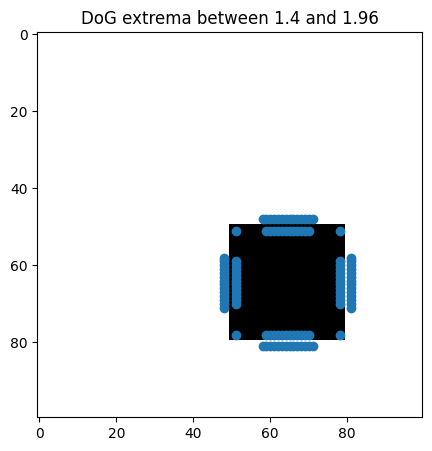

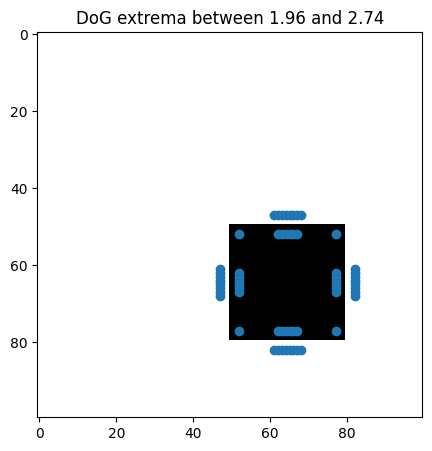

In [ ]:


def DoG(image, sigmas, coord_list, plot = True):
  height, width = image.shape

  allImagesBlurred = [ndimage.gaussian_filter(image, sigma=s) for s in sigmas]

  #DoG is the elementwise difference between the images

  differences = []

  for i in range(3):         #4 sigmas --> 3 layers in between
    difference = allImagesBlurred[i+1] - allImagesBlurred[i]
    differences.append(difference)

  #finding local extrema in differences images
  for i, difference in enumerate(differences):
    coordinates = []
    threshold = 0.01 * np.max(difference)

    for row in range(1, height-1):        #since we take row +=2
      for col in range(1, width-1):
        currVal = difference[row, col]

        if np.abs(currVal) < np.abs(threshold):     #too weak; discard
          continue
        patch = difference[row-1:row+2, col-1:col+2]    #3x3 patch centered at row, col

          #is the curr pixel unique; very bright for its surroundings   #is it the largest AND is it unqiue
        if abs(currVal) == np.max(np.abs(patch)):
          coordinates.append((row,col))
          coord_list.append((row, col, currSigma))

    if plot:
      plt.figure(figsize=(5,5))
      plt.imshow(image, cmap='gray')
      if coordinates:
        coords = np.array(coordinates)
        plt.scatter(coords[:,1], coords[:,0])

      plt.title(f"DoG extrema between {sigmas[i]} and {sigmas[i+1]}")

      plt.show()

  return coord_list

sigmas = [1.0, 1.4, 1.96, 2.74]        #increasing by k = 1.4 between consecutive scales

DoG_coords_imageOne = []

DoG_coords_imageOne = DoG(imageOne, sigmas, DoG_coords_imageOne)




## 3. Rotation Experiment


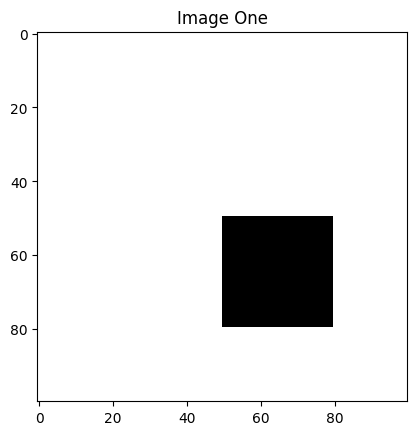

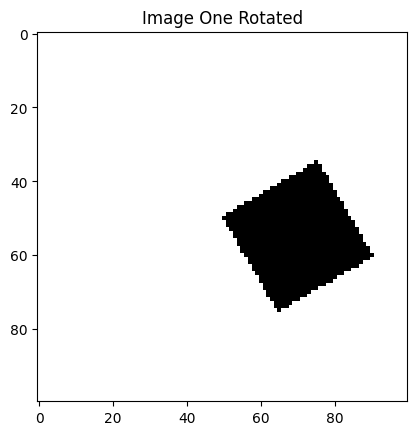

In [ ]:
#Image One for comparison
plt.imshow(imageOne, cmap = 'gray', vmin= 0, vmax = 1)
plt.title("Image One")
plt.show()

#Rotated Image
rotated_imageOne = rotate(imageOne, 30, reshape = False, mode='constant', cval=1, order=0) #order 3 smooths is a bit


plt.imshow(rotated_imageOne, cmap = 'gray', vmin= 0, vmax = 1)
plt.title("Image One Rotated")
plt.show()


Harris on Rotated Image

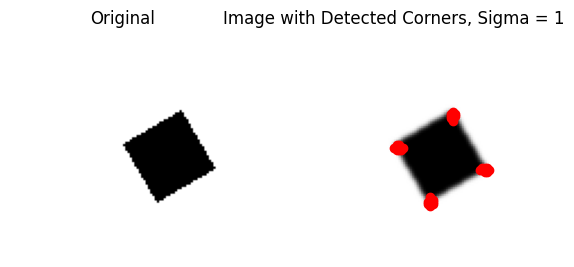

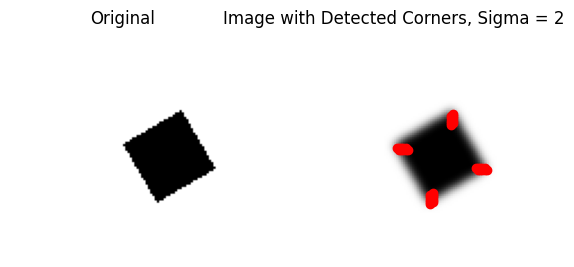

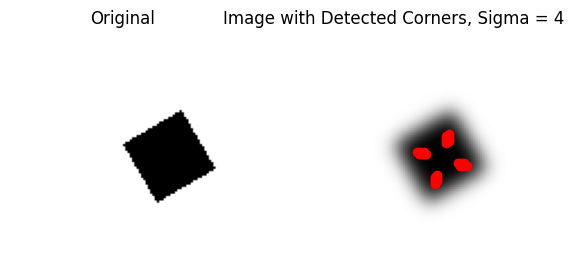

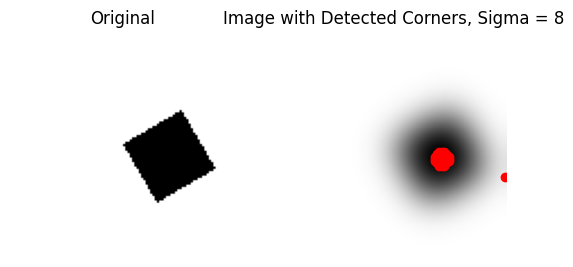

In [ ]:
sigmas = [1, 2, 4, 8]
Harris_coords_rot = []

for currSigma in sigmas:
  smoothed = ndimage.gaussian_filter(rotated_imageOne, sigma = currSigma)
  HarrisCornerDetector(smoothed, rotated_imageOne, currSigma, Harris_coords_rot, plot=True)


LoG on Rotated Image

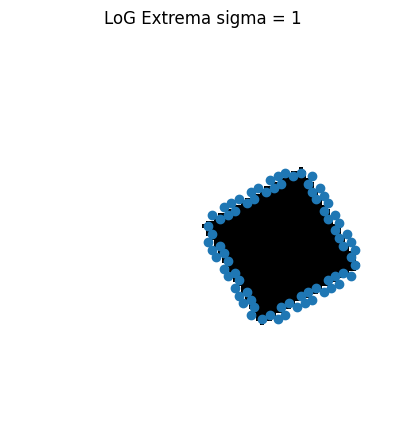

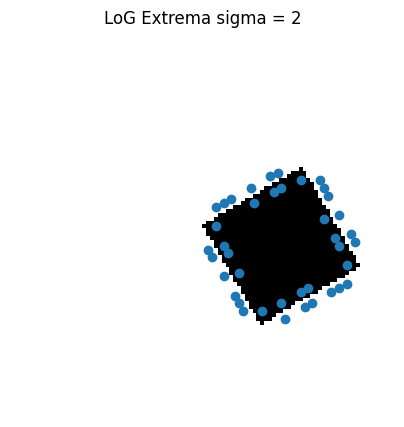

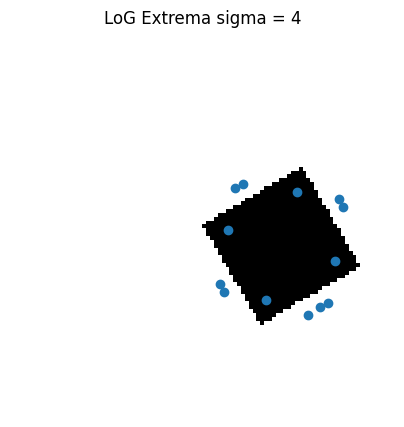

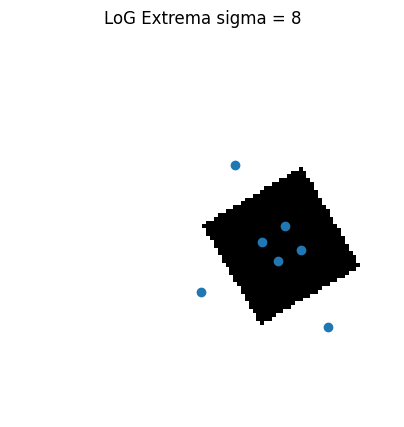

In [ ]:
LoG_coord_imageOne_rot = []

LoG_coord_imageOne_rot = LoG(rotated_imageOne, sigmas, LoG_coord_imageOne_rot)


DoG on Rotated Image

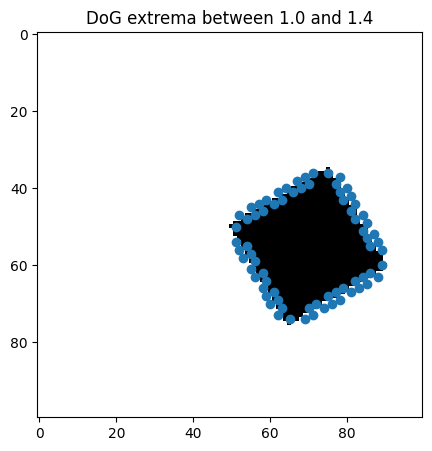

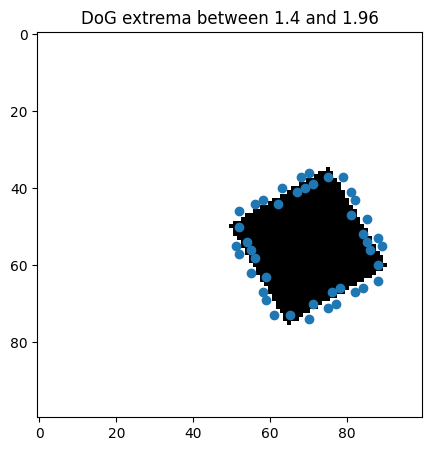

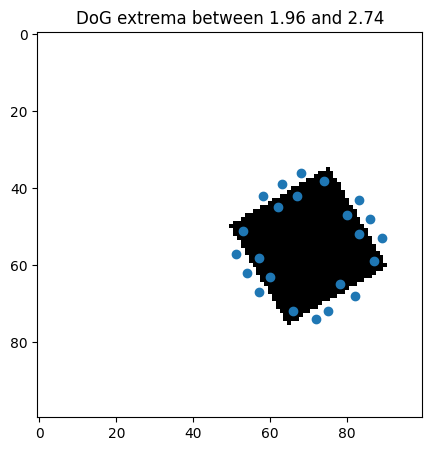

In [ ]:
sigmas = [1.0, 1.4, 1.96, 2.74]        #increasing by k = 1.4 between consecutive scales

DoG_coord_imageTwoRot = []

DoG_coord_imageTwoRot = DoG(rotated_imageOne, sigmas, DoG_coord_imageTwoRot, plot = True)


# 4. Multi-Scale Blob and Corner Detection on Image 2

## a) Gaussian Smoothing and Pyramid Construction

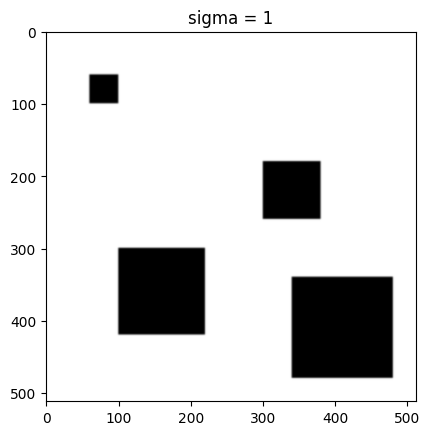

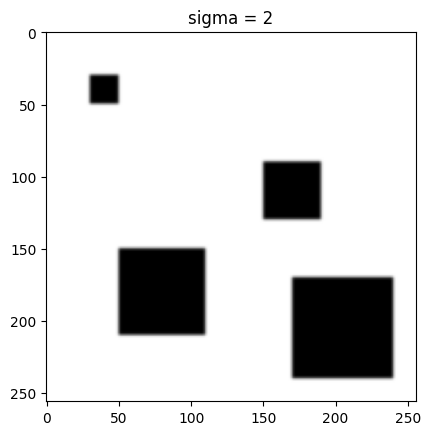

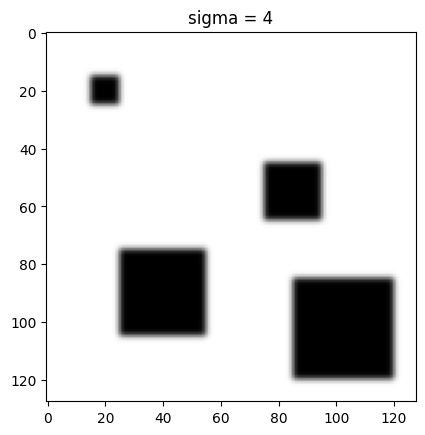

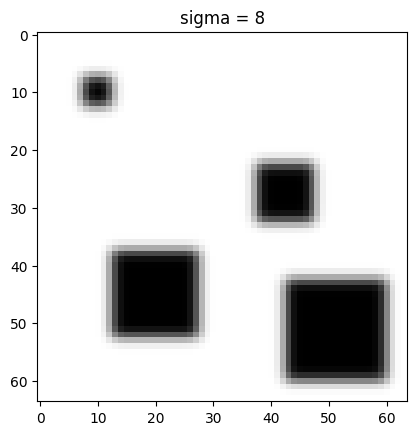

In [ ]:
pyramid = []
sigmas = [1, 2, 4, 8]

for currSigma in sigmas:
  smoothed_image = ndimage.gaussian_filter(imageTwo, sigma=currSigma)

  #downsample by 2^(log_2(sigma)) --> sigma
  downsampled_image = smoothed_image[::currSigma, ::currSigma]

  pyramid.append((currSigma, downsampled_image))

for i, (sigma, downsampled_image) in enumerate(pyramid):
  plt.title(f"sigma = {sigma}")
  plt.imshow(downsampled_image, cmap='gray')
  plt.show()


## b) Harris Corner at Multiple Scales


i) Harris detector on full resolution smoothed image (pure scale-space analysis)

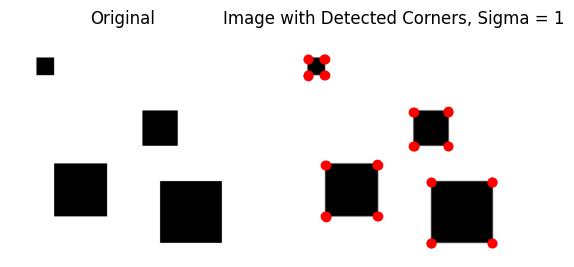

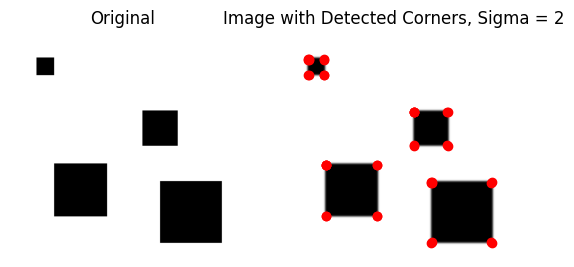

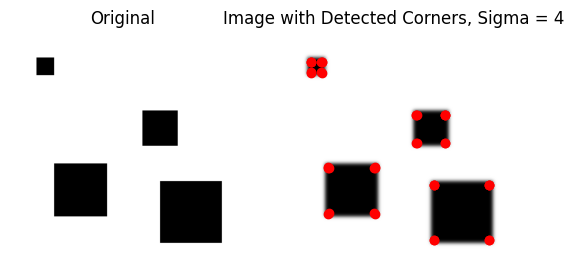

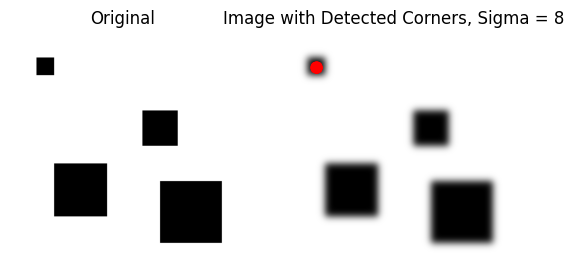

In [ ]:
Harris_coords_imageTwoFull = []

for currSigma in sigmas:
  smoothed = ndimage.gaussian_filter(imageTwo, sigma = currSigma)
  HarrisCornerDetector(smoothed, imageTwo, currSigma, Harris_coords_imageTwoFull, plot = True)

ii) Harris detector on downsampled images (pyramid representation)

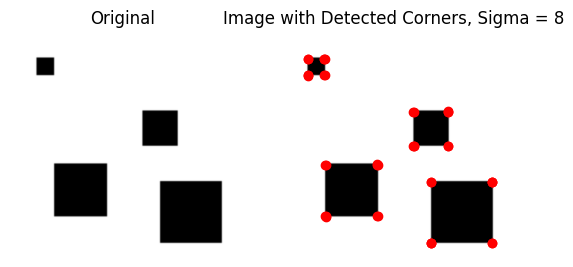

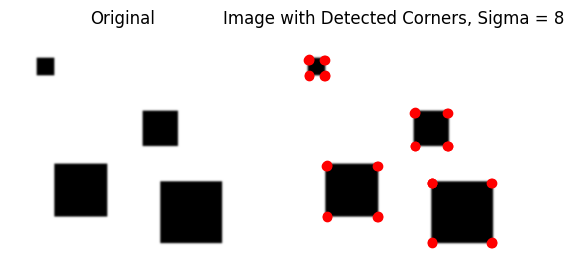

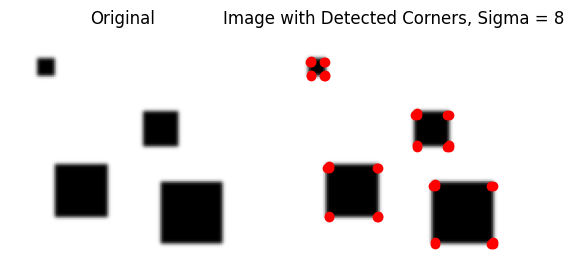

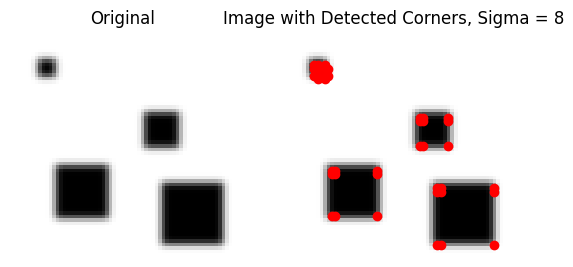

In [ ]:
Harr_coords_imageTwoDown = []

for sigma, downsampled_image in pyramid:
  HarrisCornerDetector(downsampled_image, downsampled_image, currSigma, Harr_coords_imageTwoDown, plot = True)

## c) LoG on Gaussian Pyramid



a) On original full scale image

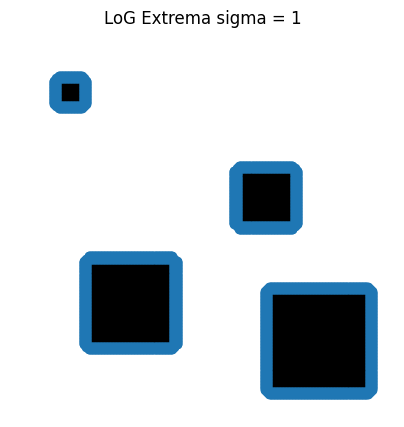

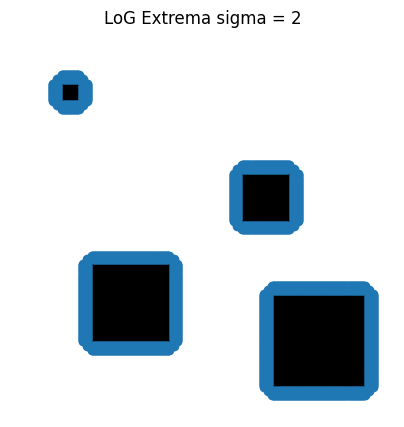

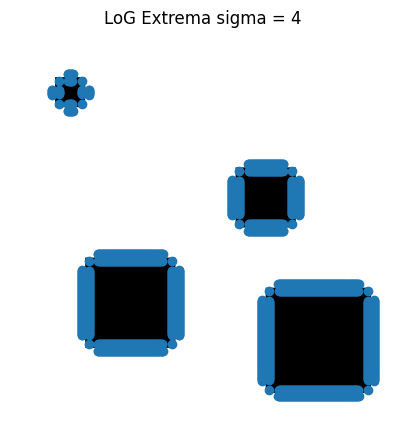

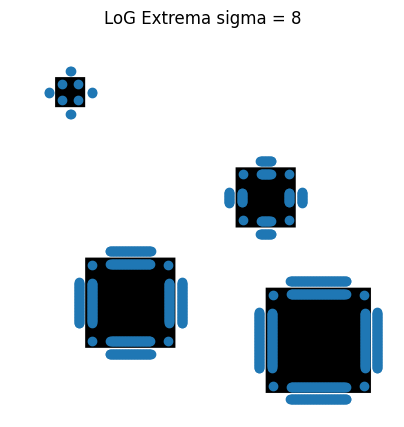

In [ ]:
sigmas = [1,2,4,8]

LoG_coords_imageTwoFull = []

LoG_coords_imageTwoFull = LoG(imageTwo, sigmas, LoG_coords_imageTwoFull)

b) On downsampled images

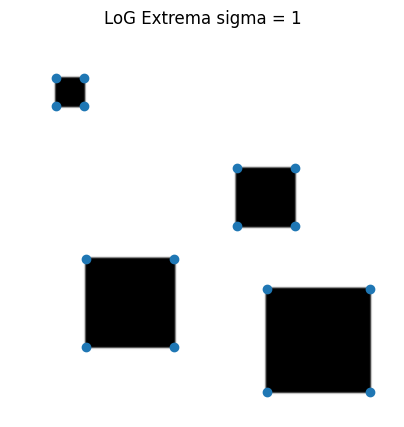

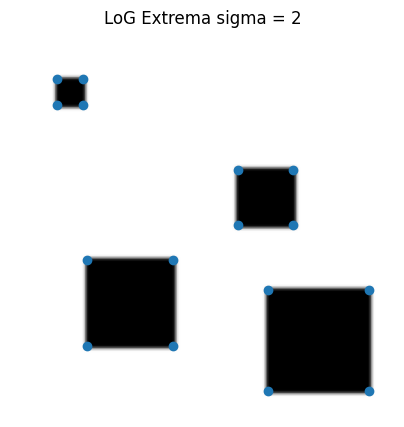

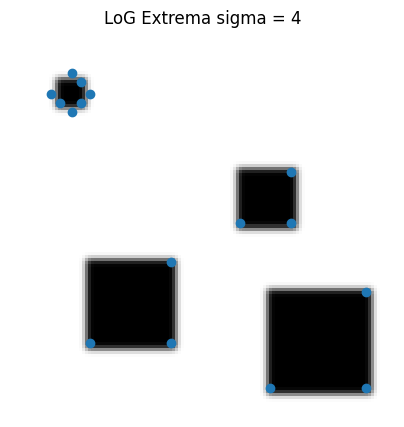

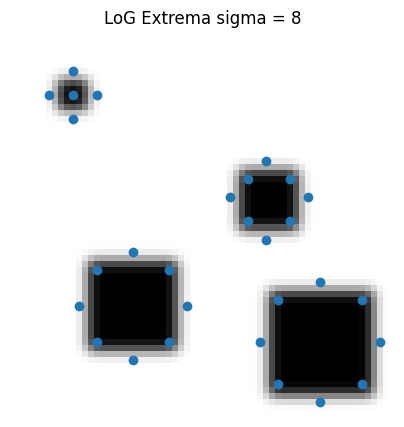

In [ ]:

for currSigma, downsampled_image in pyramid:
  height, width = downsampled_image.shape
  n = 1   # 1 sigma per level

  #LoG
  LoG_image = ndimage.gaussian_laplace(downsampled_image, sigma=1)    #already smoothed,

  #normalize by multiplying with sigma squared
  LoG_image = (currSigma ** 2) * LoG_image

  threshold = 0.05 * np.max(np.abs(LoG_image)) # 5% --> from canvas clarification

  coordinates = []      #to collect corner / interest points

  #looping through all pixels except borders
  for row in range(1, height - 1):
    for col in range(1, width - 1):
      value = LoG_image[row, col]           #curr pixel value

      #skipping weak responses
      if abs(value) < threshold:
        continue

      #extract a 3x3 local patch around (row, col)
      patch = LoG_image[row-1 : row+2, col-1:col+2]

      #checking if current pixel = unique extrema by local magnitude
      if abs(value) == np.max(np.abs(patch)) and np.sum(np.abs(patch) == np.abs(value)) == 1:
        coordinates.append((row,col))   #store local max point


  plt.figure(figsize=(5,5))
  plt.imshow(downsampled_image, cmap="gray")

  if coordinates:
    coords = np.array(coordinates)
    plt.scatter(coords[:,1], coords[:,0])

  plt.title(f"LoG Extrema sigma = {currSigma}")
  plt.axis("off")
  plt.show()





## d) Mapping and Visualization

In [ ]:
#getting DoG coordinates on image 2
DoG_coords_imageTwo = []

sigmas = [1,2,4,8]

DoG_coords_imageTwo = []

DoG_coords_imageTwo = DoG(imageTwo, sigmas, DoG_coords_imageTwo, plot=False)



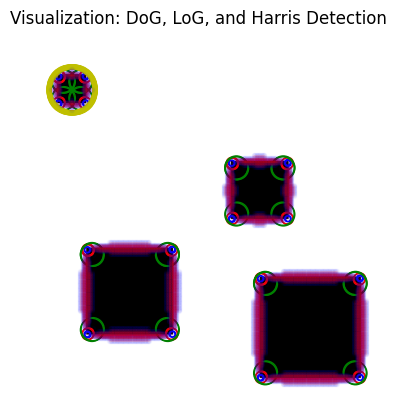

In [ ]:
#mapping everything onto image2

plt.imshow(imageTwo, cmap='gray')
c = 4
colors = {1: 'b', 2: 'r', 4: 'g', 8:'y'}


plt.title("Visualization: DoG, LoG, and Harris Detection")

#Harris --> small red points
for y, x, sigma in Harris_coords_imageTwoFull:
  color=colors.get(sigma, 'w')
  circle = plt.Circle((x,y), radius=c*sigma,color=color, fill = False)
  plt.gca().add_patch(circle)

for y, x, sigma in LoG_coords_imageTwoFull:
    plt.plot(x, y, 'bo', markersize=3, alpha = 0.03)  #blue dots for LoG

for y, x, sigma in DoG_coords_imageTwo:   #red dots for DoG
    plt.plot(x, y, 'ro', markersize=3, alpha = 0.03)


plt.axis("off")
plt.show()




In [ ]:
DoG_coords_imageTwo

[(58, 68, 8),
 (58, 69, 8),
 (58, 70, 8),
 (58, 71, 8),
 (58, 72, 8),
 (58, 73, 8),
 (58, 74, 8),
 (58, 75, 8),
 (58, 76, 8),
 (58, 77, 8),
 (58, 78, 8),
 (58, 79, 8),
 (58, 80, 8),
 (58, 81, 8),
 (58, 82, 8),
 (58, 83, 8),
 (58, 84, 8),
 (58, 85, 8),
 (58, 86, 8),
 (58, 87, 8),
 (58, 88, 8),
 (58, 89, 8),
 (58, 90, 8),
 (58, 91, 8),
 (61, 61, 8),
 (61, 69, 8),
 (61, 70, 8),
 (61, 71, 8),
 (61, 72, 8),
 (61, 73, 8),
 (61, 74, 8),
 (61, 75, 8),
 (61, 76, 8),
 (61, 77, 8),
 (61, 78, 8),
 (61, 79, 8),
 (61, 80, 8),
 (61, 81, 8),
 (61, 82, 8),
 (61, 83, 8),
 (61, 84, 8),
 (61, 85, 8),
 (61, 86, 8),
 (61, 87, 8),
 (61, 88, 8),
 (61, 89, 8),
 (61, 90, 8),
 (61, 98, 8),
 (68, 58, 8),
 (68, 101, 8),
 (69, 58, 8),
 (69, 61, 8),
 (69, 98, 8),
 (69, 101, 8),
 (70, 58, 8),
 (70, 61, 8),
 (70, 98, 8),
 (70, 101, 8),
 (71, 58, 8),
 (71, 61, 8),
 (71, 98, 8),
 (71, 101, 8),
 (72, 58, 8),
 (72, 61, 8),
 (72, 98, 8),
 (72, 101, 8),
 (73, 58, 8),
 (73, 61, 8),
 (73, 98, 8),
 (73, 101, 8),
 (74, 58, 8),
